In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [ ]:
## read the dataset
df=pd.read_csv("weight-height.csv")
df.head()

,Height,Weight
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'height')

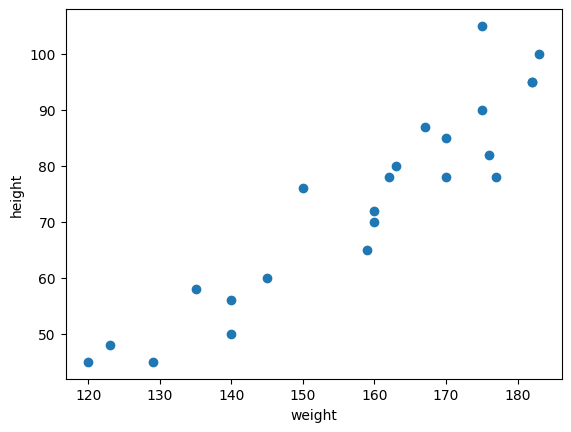

In [ ]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("weight")
plt.ylabel("height")

In [ ]:
## divide our dataset into independent and dependent
x=df[['Weight']]   ## independent
y=df['Height']   ## dependent

In [ ]:
## train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [ ]:
x.shape

(23, 1)

In [ ]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((18, 1), (5, 1), (18,), (5,))

In [ ]:
## standardise the dataset train independent data
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [ ]:
x_train.head()

,Weight
12,175
1,135
13,183
5,162
2,123


In [ ]:
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

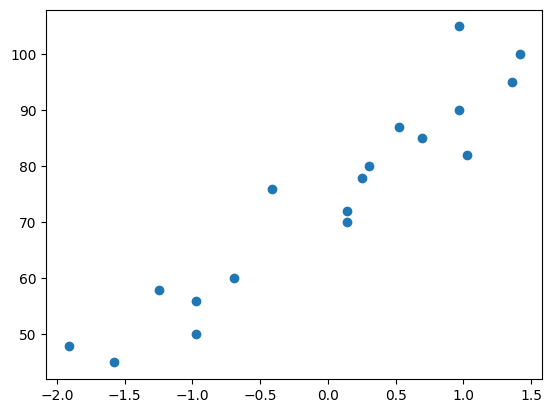

In [ ]:
plt.scatter(x_train,y_train)

In [ ]:
## train simple linear regression
from sklearn.linear_model import LinearRegression

In [ ]:
regressor=LinearRegression()

In [ ]:
regressor.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
print("The slope or coefficient of weight is:",regressor.coef_)
print("Inercept:", regressor.intercept_)

The slope or coefficient of weight is: [16.71556824]
Inercept: 74.27777777777777


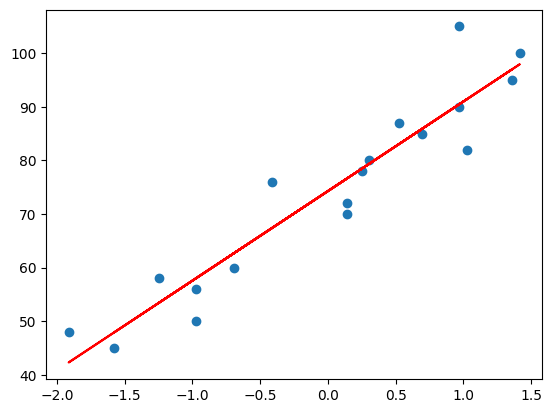

In [ ]:
plt.scatter(x_train,y_train)
plt.plot(x_train,regressor.predict(x_train),'r')

In [ ]:
y_pred_test=regressor.predict(x_test)

In [ ]:
y_pred_test,y_test

(array([92.36074777, 85.86942521, 39.50283548, 96.99740674, 75.66877547]),
 15    78
 9     78
 0     45
 8     95
 17    65
 Name: Height, dtype: int64)

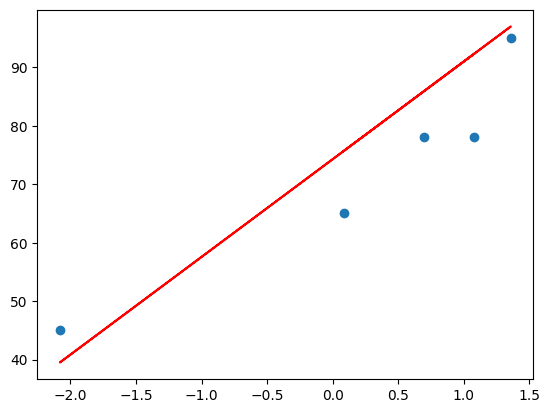

In [ ]:
plt.scatter(x_test,y_test)
plt.plot(x_test,regressor.predict(x_test),'r')

In [ ]:
## performance metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [ ]:
mse=mean_squared_error(y_test,y_pred_test)
mae=mean_absolute_error(y_test,y_pred_test)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

83.23803021031195
8.078703941181502
9.123487831433325


In [ ]:
score=r2_score(y_test,y_pred_test)
score

0.6981504561563971

In [ ]:
1-(1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)

0.5975339415418628

In [ ]:
regressor

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
## new datapoint weight is 80
scaled_weight=scaler.transform([[80]])
scaled_weight

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[-4.29947777]])

In [ ]:
scaled_weight[0]

array([-4.29947777])

In [ ]:
print("The height prediction for weight 80kg is:",regressor.predict([scaled_weight[0]]))

The height prediction for weight 80kg is: [2.40956371]


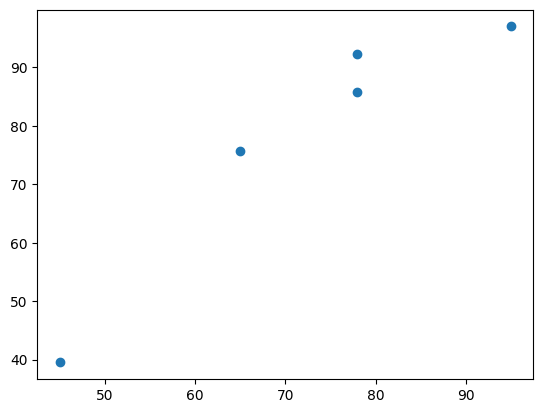

In [ ]:
## Assumptiom
## plot a scatter plot for the prediction
plt.scatter(y_test,y_pred_test)

In [ ]:
## residuals
residuals=y_test-y_pred_test
residuals

15   -14.360748
9     -7.869425
0      5.497165
8     -1.997407
17   -10.668775
Name: Height, dtype: float64

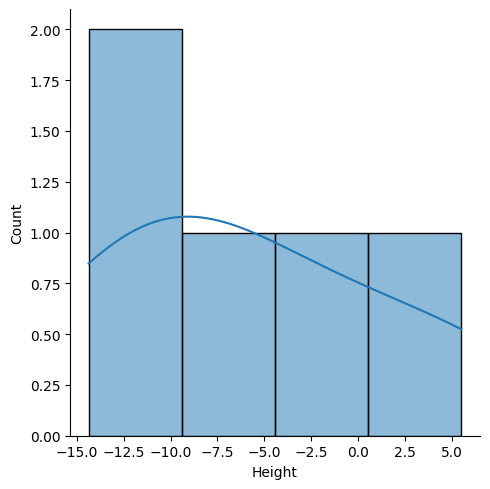

In [ ]:
## plot this residuals
import seaborn as sns
sns.displot(residuals,kde=True)

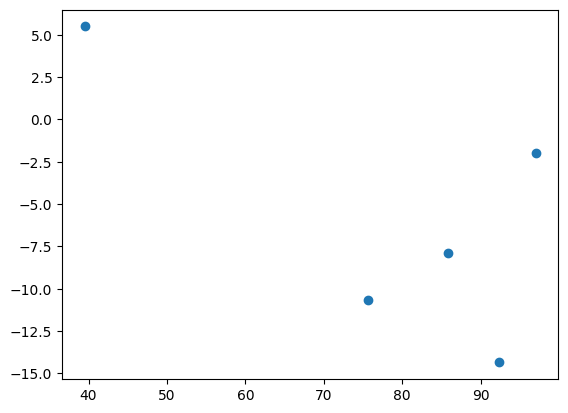

In [ ]:
## uniform distribution
plt.scatter(y_pred_test,residuals)